In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..").resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIG_DIR = BASE_DIR / "figures" / "part1"
APPENDIX_TABLE_DIR = BASE_DIR / "tables" / "appendix"

FIG_DIR.mkdir(parents=True, exist_ok=True)
APPENDIX_TABLE_DIR.mkdir(parents=True, exist_ok=True)

part1 = pd.read_csv(PROCESSED_DIR / "audusd_part1_corrected.csv", parse_dates=["Date"])
part1 = part1.sort_values("Date").reset_index(drop=True)

print("Shape:", part1.shape)
print("Start date:", part1["Date"].min())
print("End date:", part1["Date"].max())


assert np.allclose(
    part1["uip_deviation"],
    part1["uip_implied_change"] - part1["actual_fx_change"]
)

assert np.allclose(
    part1["ppp_deviation"],
    part1["ppp_implied_change"] - part1["actual_fx_change"]
)

part1.head()

Shape: (179, 12)
Start date: 2009-02-28 00:00:00
End date: 2023-12-31 00:00:00


,Date,spot,fx_return,rate_au,rate_us,infl_au,infl_us,actual_fx_change,uip_implied_change,ppp_implied_change,uip_deviation,ppp_deviation
0,2009-02-28,0.642219,0.005827,3.35,0.16,0.000363,0.004961,0.005827,-0.002658,0.004597,-0.008485,-0.001230
1,2009-03-31,0.691802,0.074370,3.25,0.17,0.000363,0.002429,0.074370,-0.002567,0.002065,-0.076937,-0.072304
2,2009-04-30,0.726691,0.049202,3.06,0.04,0.001659,0.002493,0.049202,-0.002517,0.000834,-0.051719,-0.048368
3,2009-05-31,0.801025,0.097391,3.00,0.14,0.001657,0.002885,0.097391,-0.002383,0.001228,-0.099774,-0.096163
4,2009-06-30,0.806192,0.006429,3.00,0.17,0.001654,0.008553,0.006429,-0.002358,0.006899,-0.008787,0.000471


In [27]:
appendix_table_A2 = pd.DataFrame({
    "Series": [
        "Actual monthly change in S(USD/AUD)",
        "UIP-implied monthly change",
        "PPP-implied monthly change",
        "UIP deviation: model-implied minus actual",
        "PPP deviation: model-implied minus actual"
    ],
    "Mean": [
        part1["actual_fx_change"].mean(),
        part1["uip_implied_change"].mean(),
        part1["ppp_implied_change"].mean(),
        part1["uip_deviation"].mean(),
        part1["ppp_deviation"].mean()
    ],
    "Standard deviation": [
        part1["actual_fx_change"].std(),
        part1["uip_implied_change"].std(),
        part1["ppp_implied_change"].std(),
        part1["uip_deviation"].std(),
        part1["ppp_deviation"].std()
    ],
    "Minimum": [
        part1["actual_fx_change"].min(),
        part1["uip_implied_change"].min(),
        part1["ppp_implied_change"].min(),
        part1["uip_deviation"].min(),
        part1["ppp_deviation"].min()
    ],
    "Maximum": [
        part1["actual_fx_change"].max(),
        part1["uip_implied_change"].max(),
        part1["ppp_implied_change"].max(),
        part1["uip_deviation"].max(),
        part1["ppp_deviation"].max()
    ]
})

appendix_table_A2 = appendix_table_A2.round(6)

appendix_table_A2.to_csv(
    APPENDIX_TABLE_DIR / "appendix_table_A2_descriptive_statistics_part1.csv",
    index=False
)

appendix_table_A2

,Series,Mean,Standard deviation,Minimum,Maximum
0,Actual monthly change in S(USD/AUD),0.000373,0.033698,-0.089228,0.097391
1,UIP-implied monthly change,-0.001206,0.001596,-0.003950,0.001233
2,PPP-implied monthly change,-0.000076,0.003350,-0.009147,0.011982
3,UIP deviation: model-implied minus actual,-0.001580,0.033852,-0.099774,0.085286
4,PPP deviation: model-implied minus actual,-0.000450,0.033730,-0.096163,0.088772


In [28]:
def plot_parity_scatter(
    data,
    x_col,
    y_col,
    deviation_col,
    title,
    x_label,
    y_label,
    filename,
    n_labels=5
):
    fig, ax = plt.subplots(figsize=(8, 7))

    ax.scatter(
        data[x_col],
        data[y_col],
        alpha=0.75,
        label="Monthly observations"
    )

    lower = min(data[x_col].min(), data[y_col].min())
    upper = max(data[x_col].max(), data[y_col].max())
    padding = (upper - lower) * 0.08

    lower -= padding
    upper += padding

    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        linewidth=1.5,
        label="45-degree line"
    )

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)

    largest = data.loc[data[deviation_col].abs().nlargest(n_labels).index]

    for _, row in largest.iterrows():
        ax.annotate(
            row["Date"].strftime("%Y-%m"),
            xy=(row[x_col], row[y_col]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.legend()
    ax.grid(True)
    fig.tight_layout()

    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

In [29]:
def plot_actual_vs_implied(
    data,
    implied_col,
    title,
    implied_label,
    filename
):
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(
        data["Date"],
        data["actual_fx_change"],
        label="Actual monthly change in S(USD/AUD)"
    )

    ax.plot(
        data["Date"],
        data[implied_col],
        label=implied_label
    )

    ax.axhline(0, linewidth=0.8)

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Monthly log change")
    ax.legend()
    ax.grid(True)
    fig.tight_layout()

    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

In [30]:
def plot_deviations(
    data,
    deviation_col,
    title,
    y_label,
    filename,
    n_labels=6
):
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(
        data["Date"],
        data[deviation_col],
        label="Model-implied minus actual"
    )

    ax.axhline(0, linewidth=0.8)

    dev_std = data[deviation_col].std()

    ax.axhline(
        2 * dev_std,
        linestyle="--",
        linewidth=0.8,
        label="+/- 2 standard deviations"
    )

    ax.axhline(
        -2 * dev_std,
        linestyle="--",
        linewidth=0.8
    )

    largest = data.loc[data[deviation_col].abs().nlargest(n_labels).index]

    for _, row in largest.iterrows():
        ax.annotate(
            row["Date"].strftime("%Y-%m"),
            xy=(row["Date"], row[deviation_col]),
            xytext=(0, 10 if row[deviation_col] >= 0 else -15),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel(y_label)
    ax.legend()
    ax.grid(True)
    fig.tight_layout()

    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

In [31]:
def plot_actual_vs_implied(
    data,
    implied_col,
    title,
    implied_label,
    filename
):
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(
        data["Date"],
        data["actual_fx_change"],
        label="Actual monthly change in S(USD/AUD)"
    )

    ax.plot(
        data["Date"],
        data[implied_col],
        label=implied_label
    )

    ax.axhline(0, linewidth=0.8)

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Monthly log change")
    ax.legend()
    ax.grid(True)
    fig.tight_layout()

    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

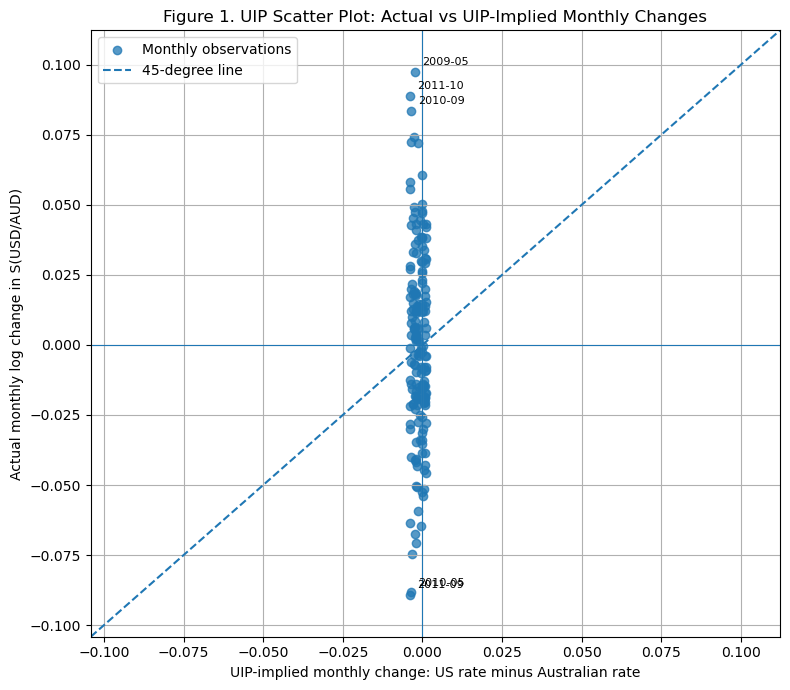

In [32]:
plot_parity_scatter(
    data=part1,
    x_col="uip_implied_change",
    y_col="actual_fx_change",
    deviation_col="uip_deviation",
    title="Figure 1. UIP Scatter Plot: Actual vs UIP-Implied Monthly Changes",
    x_label="UIP-implied monthly change: US rate minus Australian rate",
    y_label="Actual monthly log change in S(USD/AUD)",
    filename="figure1_uip_scatter_actual_vs_implied.png"
)

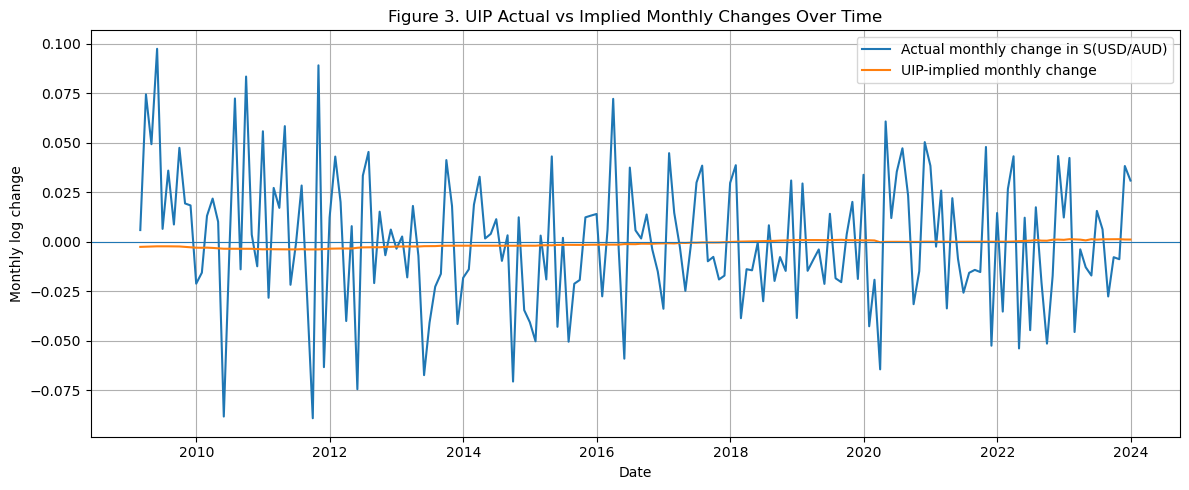

In [33]:
plot_actual_vs_implied(
    data=part1,
    implied_col="uip_implied_change",
    title="Figure 3. UIP Actual vs Implied Monthly Changes Over Time",
    implied_label="UIP-implied monthly change",
    filename="figure3_uip_actual_vs_implied_monthly_changes.png"
)

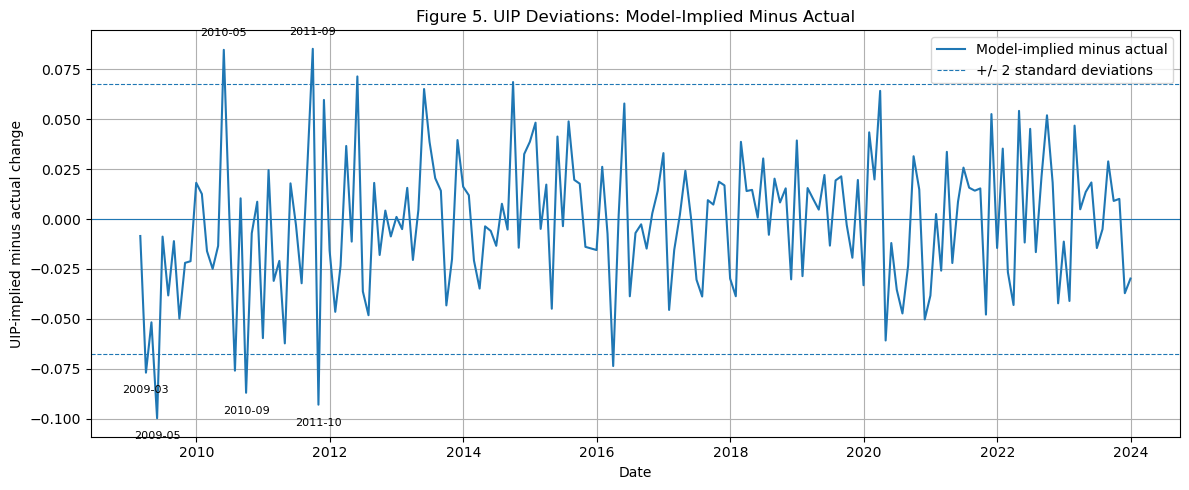

In [34]:
plot_deviations(
    data=part1,
    deviation_col="uip_deviation",
    title="Figure 5. UIP Deviations: Model-Implied Minus Actual",
    y_label="UIP-implied minus actual change",
    filename="figure5_uip_deviations_model_implied_minus_actual.png"
)

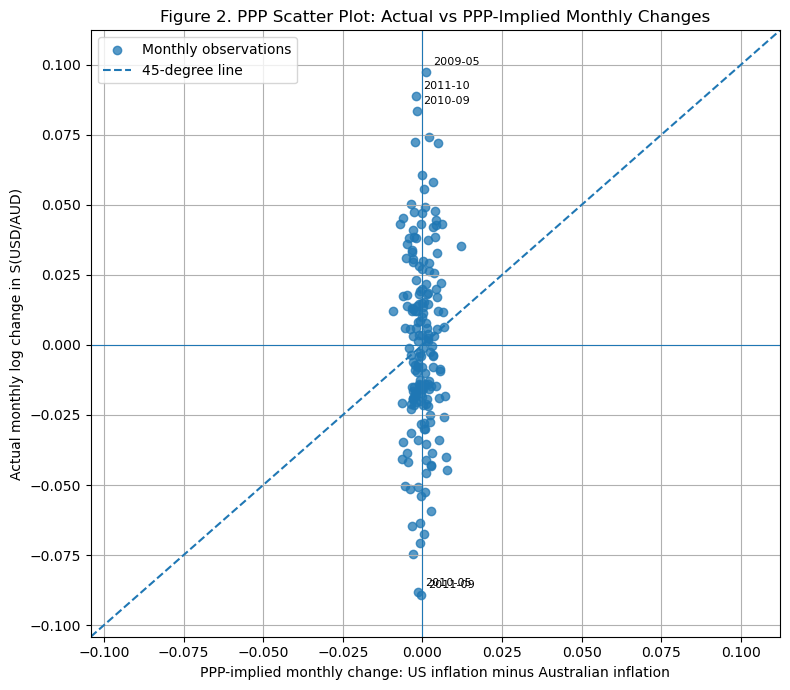

In [35]:
plot_parity_scatter(
    data=part1,
    x_col="ppp_implied_change",
    y_col="actual_fx_change",
    deviation_col="ppp_deviation",
    title="Figure 2. PPP Scatter Plot: Actual vs PPP-Implied Monthly Changes",
    x_label="PPP-implied monthly change: US inflation minus Australian inflation",
    y_label="Actual monthly log change in S(USD/AUD)",
    filename="figure2_ppp_scatter_actual_vs_implied.png"
)

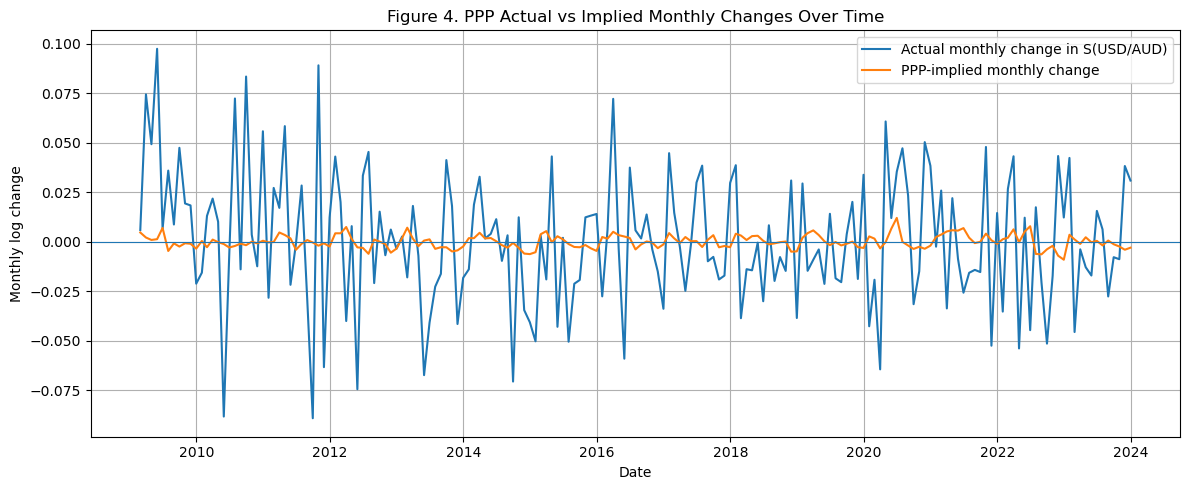

In [36]:
plot_actual_vs_implied(
    data=part1,
    implied_col="ppp_implied_change",
    title="Figure 4. PPP Actual vs Implied Monthly Changes Over Time",
    implied_label="PPP-implied monthly change",
    filename="figure4_ppp_actual_vs_implied_monthly_changes.png"
)

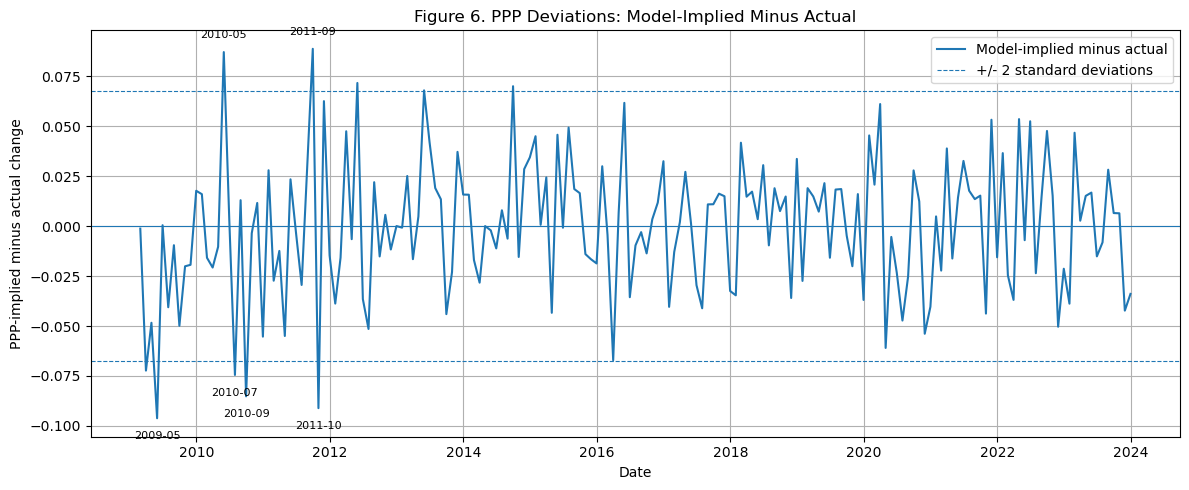

In [37]:
plot_deviations(
    data=part1,
    deviation_col="ppp_deviation",
    title="Figure 6. PPP Deviations: Model-Implied Minus Actual",
    y_label="PPP-implied minus actual change",
    filename="figure6_ppp_deviations_model_implied_minus_actual.png"
)

In [38]:
largest_uip_deviations = part1.loc[
    part1["uip_deviation"].abs().nlargest(10).index,
    [
        "Date",
        "actual_fx_change",
        "uip_implied_change",
        "uip_deviation"
    ]
].sort_values("Date")

largest_ppp_deviations = part1.loc[
    part1["ppp_deviation"].abs().nlargest(10).index,
    [
        "Date",
        "actual_fx_change",
        "ppp_implied_change",
        "ppp_deviation"
    ]
].sort_values("Date")

largest_uip_deviations.to_csv(
    APPENDIX_TABLE_DIR / "supporting_largest_uip_deviations.csv",
    index=False
)

largest_ppp_deviations.to_csv(
    APPENDIX_TABLE_DIR / "supporting_largest_ppp_deviations.csv",
    index=False
)

display(largest_uip_deviations)
display(largest_ppp_deviations)

,Date,actual_fx_change,uip_implied_change,uip_deviation
1,2009-03-31,0.074370,-0.002567,-0.076937
3,2009-05-31,0.097391,-0.002383,-0.099774
15,2010-05-31,-0.088367,-0.003600,0.084767
17,2010-07-31,0.072297,-0.003633,-0.075931
19,2010-09-30,0.083378,-0.003633,-0.087011
31,2011-09-30,-0.089228,-0.003942,0.085286
32,2011-10-31,0.089036,-0.003942,-0.092977
39,2012-05-31,-0.074568,-0.003117,0.071451
67,2014-09-30,-0.070694,-0.002067,0.068627
85,2016-03-31,0.072109,-0.001517,-0.073625


,Date,actual_fx_change,ppp_implied_change,ppp_deviation
1,2009-03-31,0.074370,0.002065,-0.072304
3,2009-05-31,0.097391,0.001228,-0.096163
15,2010-05-31,-0.088367,-0.001236,0.087131
17,2010-07-31,0.072297,-0.002191,-0.074489
19,2010-09-30,0.083378,-0.001809,-0.085187
31,2011-09-30,-0.089228,-0.000456,0.088772
32,2011-10-31,0.089036,-0.002065,-0.091100
39,2012-05-31,-0.074568,-0.002899,0.071669
51,2013-05-31,-0.067454,0.000516,0.067969
67,2014-09-30,-0.070694,-0.000647,0.070047


In [39]:

from IPython.display import display, Markdown

appendix_table_A2 = pd.DataFrame({
    "Series": [
        "Actual monthly change in S(USD/AUD)",
        "UIP-implied monthly change",
        "PPP-implied monthly change",
        "UIP deviation: model-implied minus actual",
        "PPP deviation: model-implied minus actual"
    ],
    "Mean": [
        part1["actual_fx_change"].mean(),
        part1["uip_implied_change"].mean(),
        part1["ppp_implied_change"].mean(),
        part1["uip_deviation"].mean(),
        part1["ppp_deviation"].mean()
    ],
    "Standard deviation": [
        part1["actual_fx_change"].std(),
        part1["uip_implied_change"].std(),
        part1["ppp_implied_change"].std(),
        part1["uip_deviation"].std(),
        part1["ppp_deviation"].std()
    ],
    "Minimum": [
        part1["actual_fx_change"].min(),
        part1["uip_implied_change"].min(),
        part1["ppp_implied_change"].min(),
        part1["uip_deviation"].min(),
        part1["ppp_deviation"].min()
    ],
    "Maximum": [
        part1["actual_fx_change"].max(),
        part1["uip_implied_change"].max(),
        part1["ppp_implied_change"].max(),
        part1["uip_deviation"].max(),
        part1["ppp_deviation"].max()
    ]
})

appendix_table_A2 = appendix_table_A2.round(6)

# Display with proper appendix title in notebook
display(Markdown("**Appendix Table A2. Descriptive Statistics for Actual, UIP-Implied, and PPP-Implied Monthly Changes**"))
display(appendix_table_A2)

# Save clean CSV for appendix
appendix_table_A2.to_csv(
    APPENDIX_TABLE_DIR / "appendix_table_A2_descriptive_statistics_part1.csv",
    index=False
)

**Appendix Table A2. Descriptive Statistics for Actual, UIP-Implied, and PPP-Implied Monthly Changes**

,Series,Mean,Standard deviation,Minimum,Maximum
0,Actual monthly change in S(USD/AUD),0.000373,0.033698,-0.089228,0.097391
1,UIP-implied monthly change,-0.001206,0.001596,-0.003950,0.001233
2,PPP-implied monthly change,-0.000076,0.003350,-0.009147,0.011982
3,UIP deviation: model-implied minus actual,-0.001580,0.033852,-0.099774,0.085286
4,PPP deviation: model-implied minus actual,-0.000450,0.033730,-0.096163,0.088772
